## Transcripts to Genes Annotation

## Purpose: 

* Annotate Transcripts to Genes
* Plot number of transcripts, genes, no annotated regions 
* Find out p-values as related to relative scores
* Get Gene Lists 
* Genes annotated as function of motif size 

In [1]:
import pandas as pd
pd.set_option('display.width', 10000000)
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import glob,os

import matplotlib.pyplot as plt
import seaborn as sns

## Load Data 

In [2]:
# get all files 
files = sorted(glob.glob("../../4_bedtools_window/outputs/*"))

# save all dataframes
tables = {}

for file in files: 
    # read gzip compressed file with tab separator
    tmp = pd.read_csv(
        file, 
        sep="\t", 
        header=None
    )
    
#     tmp = tmp[tmp[2]>990]
    
    # get just the motif ID
    key = ".".join(file.split("/")[-1].split(".")[0:3])

    tables[key]= tmp
    

In [3]:
len(tables)
tables[key].head()

72

,0,1,2,3
0,ENSMUST00000000001.4,SMAD5,802,286
1,ENSMUST00000000001.4,SMAD5,803,288
2,ENSMUST00000000001.4,SMAD5,804,290
3,ENSMUST00000000001.4,SMAD5,805,291
4,ENSMUST00000000001.4,SMAD5,821,307


In [4]:
annotation_file = pd.read_csv(
    "../../../../inputs/mouse_transcripts_genes_mapping/mm10_genes_and_transcripts.tsv", 
    sep="\t" 
)

annotation_file = annotation_file.set_index("Transcript stable ID")

annotation_file.head()

annotation_file.index.size
annotation_file.index.unique().size

,Gene stable ID,Gene name
Transcript stable ID,,
ENSMUST00000082421,ENSMUSG00000064370,mt-Cytb
ENSMUST00000082419,ENSMUSG00000064368,mt-Nd6
ENSMUST00000082418,ENSMUSG00000064367,mt-Nd5
ENSMUST00000082414,ENSMUSG00000064363,mt-Nd4
ENSMUST00000084013,ENSMUSG00000065947,mt-Nd4l


103808

103808

## Annotate Transcripts to Genes

In [5]:
# for each table 
# convert transcript ids with version to stable ids 
# set the index as the stable id 
# left join against the annotation file 
# save the new table

for key in tables:

    caller = tables[key]
    
    caller[0] = caller[0].str.split(".").str[0]
    
    caller = caller.set_index(0)
    
    caller = caller.join(annotation_file, how='left')
    
    tables[key] = caller
    

# Exploratory Analysis

## Number of Transcripts, Genes, Empty Genes

In [6]:
thresholds = [900, 950, 990]

In [7]:
key

'MA1557.1.upstream_750'

In [8]:
summary_stat_df = pd.DataFrame()

for key in tables:
    for threshold in thresholds: 
    
        tmp = tables[key]

        tmp = tmp[tmp[2]>threshold]
        
        combination = "{}-{}".format(key.split(".")[-1].split("_")[-1], threshold)
        upstream_parameter = key.split(".")[-1].split("_")[-1]
        
        new_row = []
        new_row.append(combination)
        new_row.append(upstream_parameter)
        new_row.append(threshold)
        new_row.append(key.split(".")[0])
        new_row.append(tmp.index.unique().size)
        new_row.append(tmp["Gene stable ID"].unique().size)
        new_row.append(tmp["Gene stable ID"].isna().sum())
        
        new_row = pd.DataFrame(new_row).T

        summary_stat_df = pd.concat([summary_stat_df, new_row])    

In [9]:
summary_stat_df.columns=["Combination", "Upstream Parameter", "Relative Score", "Transcription Factor", "Num Transcripts", "Num Genes", "Num No Annotated Genes"]

summary_stat_df

,Combination,Upstream Parameter,Relative Score,Transcription Factor,Num Transcripts,Num Genes,Num No Annotated Genes
0,2500-900,2500,900,MA0052,41080,8758,7223
0,2500-950,2500,950,MA0052,4446,1031,500
0,2500-990,2500,990,MA0052,184,46,3
0,5000-900,5000,900,MA0052,56146,11768,12159
0,5000-950,5000,950,MA0052,6901,1625,823
0,5000-990,5000,990,MA0052,328,83,13
0,750-900,750,900,MA0052,19629,4272,2738
0,750-950,750,950,MA0052,1729,412,184
0,750-990,750,990,MA0052,69,19,2
0,2500-900,2500,900,MA0058,75152,14834,29578


In [10]:
combination_order = pd.api.types.CategoricalDtype(
    [
        "750-900",
        "750-950",
        "750-990",
        "2500-900",
        "2500-950",
        "2500-990",
        "5000-900",
        "5000-950",
        "5000-990"
    ], 
    ordered=True
)

combination_order

CategoricalDtype(categories=['750-900', '750-950', '750-990', '2500-900', '2500-950', '2500-990', '5000-900', '5000-950', '5000-990'], ordered=True, categories_dtype=object)

In [11]:
summary_stat_df["Combination"] = summary_stat_df["Combination"].astype(combination_order)

summary_stat_df.dtypes

Combination               category
Upstream Parameter          object
Relative Score              object
Transcription Factor        object
Num Transcripts             object
Num Genes                   object
Num No Annotated Genes      object
dtype: object

In [12]:
summary_stat_df = summary_stat_df.sort_values("Combination")

summary_stat_df.head()

,Combination,Upstream Parameter,Relative Score,Transcription Factor,Num Transcripts,Num Genes,Num No Annotated Genes
0,750-900,750,900,MA0867,90475,17368,47172
0,750-900,750,900,MA1104,26226,5686,4125
0,750-900,750,900,MA0072,5865,1237,764
0,750-900,750,900,MA0895,58704,11887,13014
0,750-900,750,900,MA0073,8825,1963,1287


In [13]:
summary_stat_df.sort_values("Num Genes", ascending=False)

,Combination,Upstream Parameter,Relative Score,Transcription Factor,Num Transcripts,Num Genes,Num No Annotated Genes
0,5000-900,5000,900,MA0867,107780,19576,173632
0,5000-900,5000,900,MA0739,106058,19424,88818
0,2500-900,2500,900,MA0867,104204,19402,109287
0,2500-900,2500,900,MA0739,100084,18821,57326
0,5000-900,5000,900,MA0895,98843,18654,52259
0,5000-900,5000,900,MA1522,95301,18132,52190
0,5000-900,5000,900,MA1112,93839,18006,37616
0,5000-950,5000,950,MA0867,92254,17841,36674
0,5000-900,5000,900,MA1111,92415,17791,34643
0,5000-900,5000,900,MA0523,88779,17422,32396


In [14]:
sox4_summary = summary_stat_df[summary_stat_df["Transcription Factor"]=="MA0867"]

sox4_summary

,Combination,Upstream Parameter,Relative Score,Transcription Factor,Num Transcripts,Num Genes,Num No Annotated Genes
0,750-900,750,900,MA0867,90475,17368,47172
0,750-950,750,950,MA0867,49197,10183,9973
0,750-990,750,990,MA0867,4492,1046,532
0,2500-900,2500,900,MA0867,104204,19402,109287
0,2500-950,2500,950,MA0867,77853,15490,22733
0,2500-990,2500,990,MA0867,9505,2175,1166
0,5000-900,5000,900,MA0867,107780,19576,173632
0,5000-950,5000,950,MA0867,92254,17841,36674
0,5000-990,5000,990,MA0867,14457,3369,1712


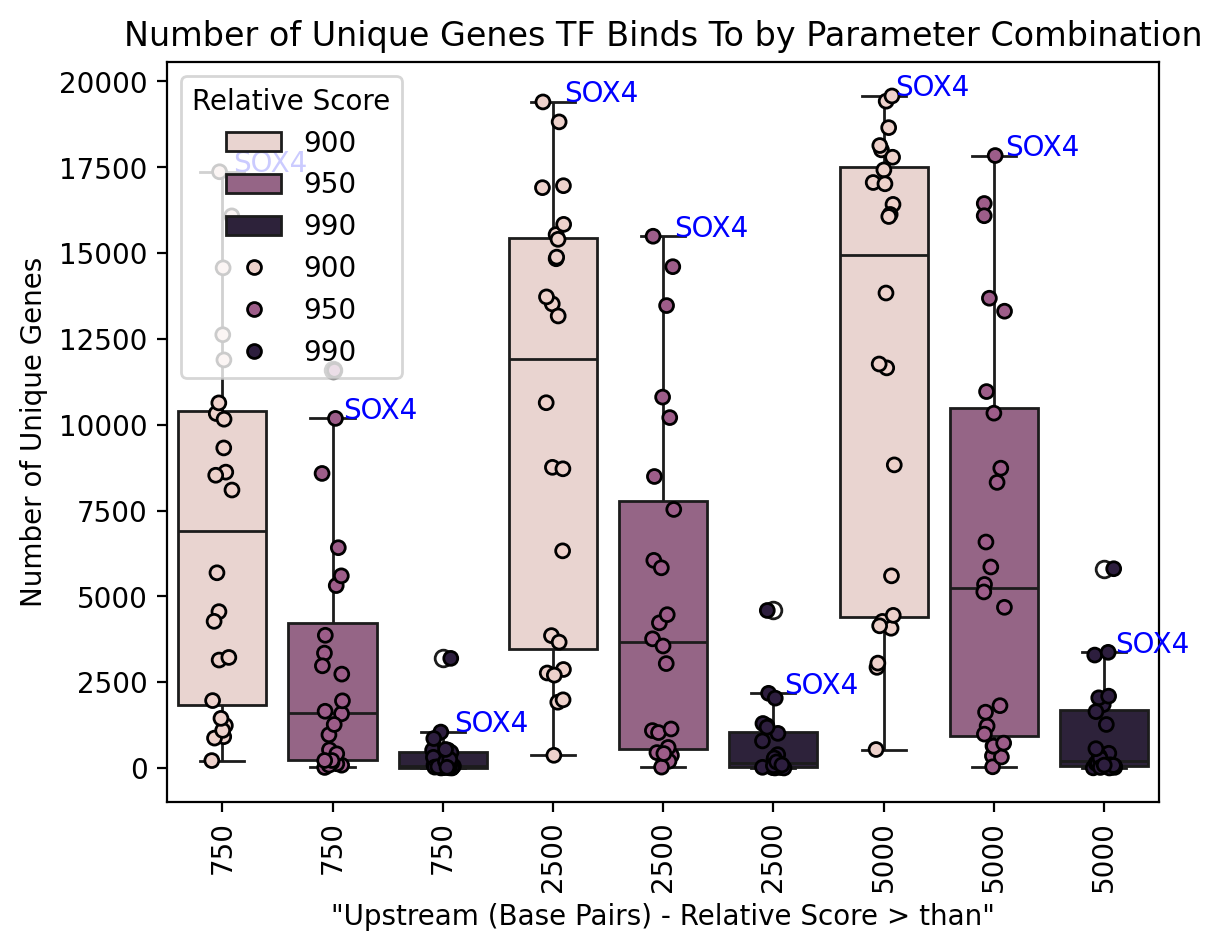

In [15]:

_=plt.figure(dpi=200)
_=plt.title("Number of Unique Genes TF Binds To by Parameter Combination")
_=sns.boxplot(x="Combination", y="Num Genes", data=summary_stat_df, hue="Relative Score")
_=sns.stripplot(x="Combination", y="Num Genes", data=summary_stat_df, hue="Relative Score", edgecolor="black", linewidth=1)
_=plt.xticks(
    rotation=90,
    ticks = list(range(9)), 
    labels = ["750","750","750","2500","2500","2500","5000","5000", "5000"]
)

_=plt.xlabel('"Upstream (Base Pairs) - Relative Score > than"')
_=plt.ylabel("Number of Unique Genes")

for counter, num_genes in enumerate(sox4_summary["Num Genes"].to_list()): 
    
    _= plt.text(counter+0.1, num_genes, "SOX4", color="blue")

# plt.savefig("/home/jve4pt/num_genes_sox4_highlighted_november_16_2023.png", dpi=200, bbox_inches = "tight")

## Genes Annotated as Function of Motif Size

In [16]:
df_tmp =summary_stat_df[summary_stat_df["Upstream Parameter"]=='750'].sort_values(by=["Num Genes"])
df_tmp.head()

,Combination,Upstream Parameter,Relative Score,Transcription Factor,Num Transcripts,Num Genes,Num No Annotated Genes
0,750-990,750,990,MA0073,0,0,0
0,750-990,750,990,MA0839,0,0,0
0,750-990,750,990,MA1541,14,5,1
0,750-990,750,990,MA0072,32,6,5
0,750-990,750,990,MA0520,21,7,3


In [17]:
motif_ids = df_tmp["Transcription Factor"].str.split(".").str[0].to_list()
motif_ids

['MA0073',
 'MA0839',
 'MA1541',
 'MA0072',
 'MA0520',
 'MA1114',
 'MA0523',
 'MA0839',
 'MA0052',
 'MA0783',
 'MA1104',
 'MA0677',
 'MA0506',
 'MA0783',
 'MA0592',
 'MA0073',
 'MA1557',
 'MA1541',
 'MA0677',
 'MA0058',
 'MA0839',
 'MA1114',
 'MA0072',
 'MA0076',
 'MA0895',
 'MA0052',
 'MA1112',
 'MA0739',
 'MA1111',
 'MA1557',
 'MA0161',
 'MA0489',
 'MA0677',
 'MA0783',
 'MA0506',
 'MA0867',
 'MA1541',
 'MA0072',
 'MA1104',
 'MA1114',
 'MA0523',
 'MA0520',
 'MA0592',
 'MA0073',
 'MA0895',
 'MA0489',
 'MA0506',
 'MA1522',
 'MA1557',
 'MA0076',
 'MA1112',
 'MA0052',
 'MA0592',
 'MA0058',
 'MA1111',
 'MA1104',
 'MA0739',
 'MA0520',
 'MA0489',
 'MA0161',
 'MA0161',
 'MA0523',
 'MA0058',
 'MA0867',
 'MA1111',
 'MA1112',
 'MA1522',
 'MA0895',
 'MA0076',
 'MA1522',
 'MA0739',
 'MA0867']

In [18]:
motif_lengths = []

for motif in motif_ids: 
    file = glob.glob("../../3_bedtools_intersect/outputs/*{}*750*".format(motif))[0]
    file
    
    tmp_df = pd.read_csv(file, sep="\t", compression="gzip", nrows=2, header=None)   
    
    tmp_df["Difference"] = tmp_df[2] - tmp_df[1]

    motif_lengths.append(tmp_df["Difference"][0])

motif_lengths

'../../3_bedtools_intersect/outputs/MA0073.1.upstream_750.bed.gz'

'../../3_bedtools_intersect/outputs/MA0839.1.upstream_750.bed.gz'

'../../3_bedtools_intersect/outputs/MA1541.1.upstream_750.bed.gz'

'../../3_bedtools_intersect/outputs/MA0072.1.upstream_750.bed.gz'

'../../3_bedtools_intersect/outputs/MA0520.1.upstream_750.bed.gz'

...

'../../3_bedtools_intersect/outputs/MA0076.2.upstream_750.bed.gz'

'../../3_bedtools_intersect/outputs/MA1522.1.upstream_750.bed.gz'

'../../3_bedtools_intersect/outputs/MA0739.1.upstream_750.bed.gz'

'../../3_bedtools_intersect/outputs/MA0867.2.upstream_750.bed.gz'

[20,
 14,
 17,
 14,
 15,
 17,
 14,
 14,
 15,
 12,
 13,
 14,
 15,
 12,
 13,
 20,
 10,
 17,
 14,
 10,
 14,
 17,
 14,
 11,
 10,
 15,
 12,
 9,
 11,
 10,
 11,
 12,
 14,
 12,
 15,
 10,
 17,
 14,
 13,
 17,
 14,
 15,
 13,
 20,
 10,
 12,
 15,
 11,
 10,
 11,
 12,
 15,
 13,
 10,
 11,
 13,
 9,
 15,
 12,
 11,
 11,
 14,
 10,
 10,
 11,
 12,
 11,
 10,
 11,
 11,
 9,
 10]

<Figure size 1280x960 with 0 Axes>

Text(0.5, 1.0, "NOTE: 750 upstream parameter used but shouldn't matter")

Text(0.5, 0.98, 'Genes Annotated per Motif vs. Motif Length')

Text(0.5, 0, 'Number of Genes Annotated')

Text(0, 0.5, 'Motif Length')

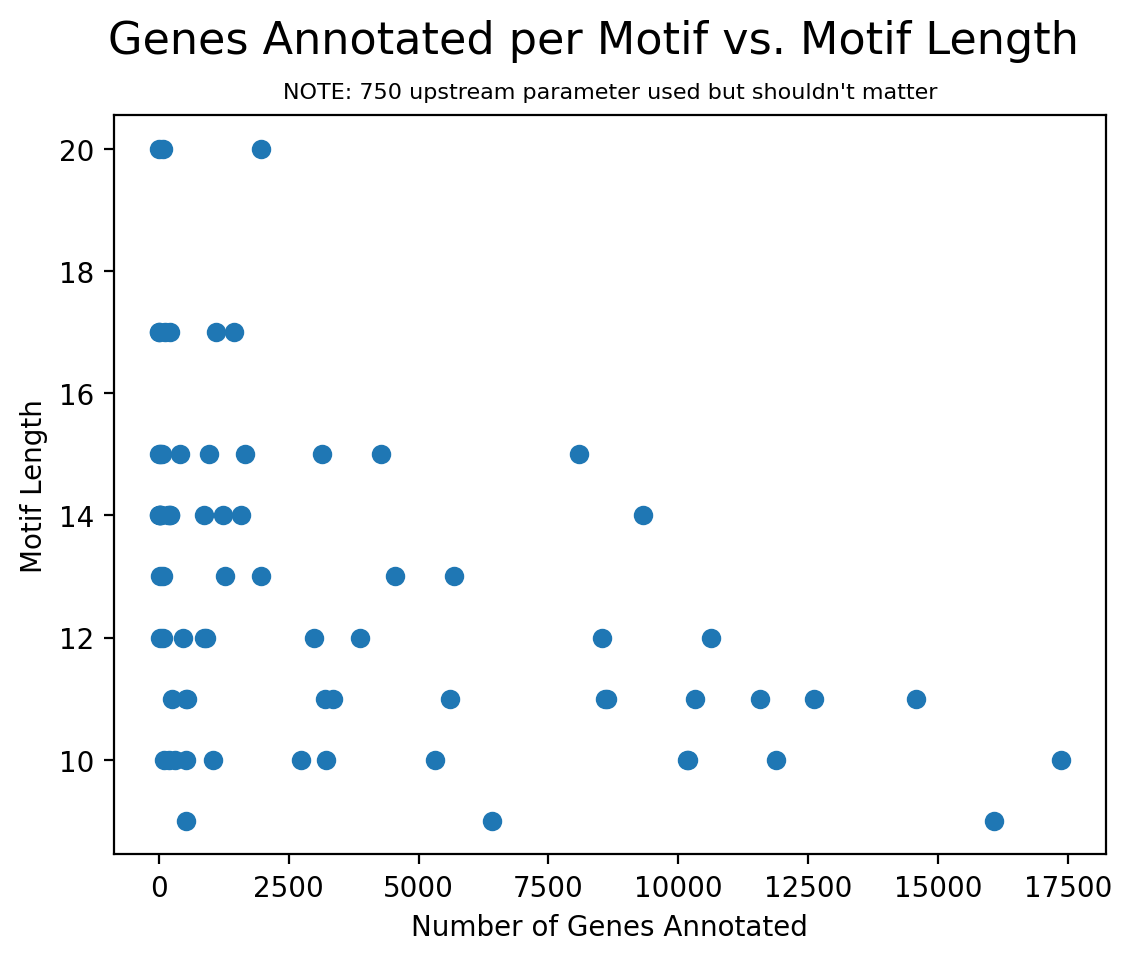

In [19]:
plt.figure(dpi=200)
plt.title("NOTE: 750 upstream parameter used but shouldn't matter", fontsize=8)
plt.suptitle("Genes Annotated per Motif vs. Motif Length", fontsize=16)
plt.xlabel("Number of Genes Annotated")
plt.ylabel("Motif Length")
plt.scatter(df_tmp["Num Genes"].to_list(), motif_lengths)

## P-Values as Function of Relative Scores

In [20]:
p_values_950 = []
p_values_990 = []

for key in tables:

    if "upstream_750" in key: 
    
        tmp = tables[key]

        p_values_950.extend(tmp[tmp[2]>950][3].to_list())

        p_values_990.extend(tmp[tmp[2]>990][3].to_list())



In [21]:
col_1 = []
col_2 = []

for num in p_values_950: 
    col_1.append(num)
    col_2.append(".95")

for num in p_values_990: 
    col_1.append(num)
    col_2.append(".99")


In [22]:
tmp_df =pd.DataFrame(col_1, col_2).reset_index()

In [23]:
tmp_df.head()

,index,0
0,.95,667
1,.95,637
2,.95,785
3,.95,698
4,.95,660


<Figure size 1280x960 with 0 Axes>

Text(0.5, 1.0, '750 Upstream')

<Axes: title={'center': '750 Upstream'}, xlabel='index', ylabel='0'>

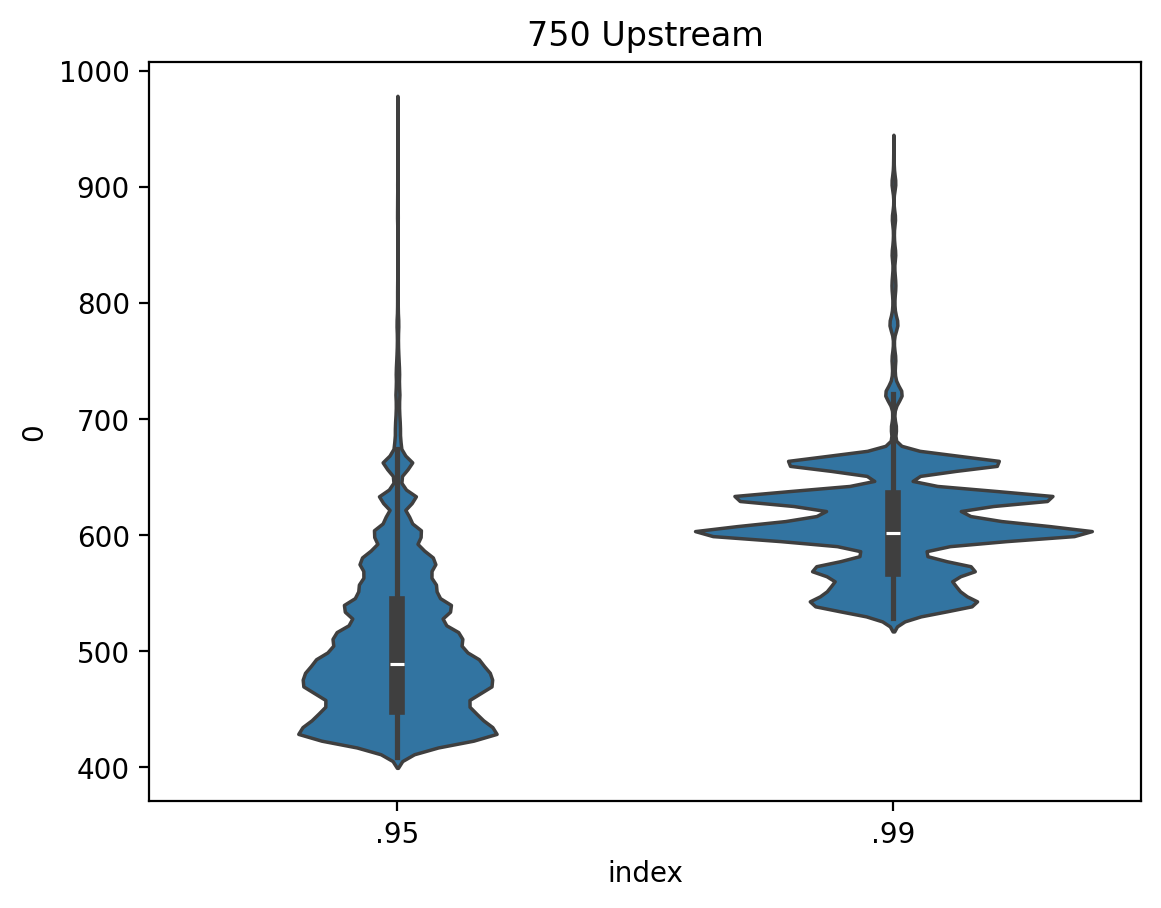

In [24]:
plt.figure(dpi=200)
plt.title("750 Upstream")
sns.violinplot(x="index", y=0, data=tmp_df)

## Gene Lists

In [25]:
all_genes = []

for key in tables:
    
    threshold = 990
    
    if "upstream_750" in key: 
        
        tmp = tables[key]

        tmp = tmp[tmp[2]>threshold].reset_index()

        tmp = tmp[[1,"Gene stable ID", "Gene name"]].drop_duplicates()

        all_genes.extend(tmp["Gene stable ID"].to_list())

In [26]:
value_counts = pd.Series(all_genes).value_counts()
value_counts.head()

ENSMUSG00000092329    11
ENSMUSG00000030849     6
ENSMUSG00000021939     6
ENSMUSG00000051747     6
ENSMUSG00000037649     6
Name: count, dtype: int64

<Figure size 1280x960 with 0 Axes>

Text(0.5, 1.0, '990 & 750 Upstream')

<BarContainer object of 20 artists>

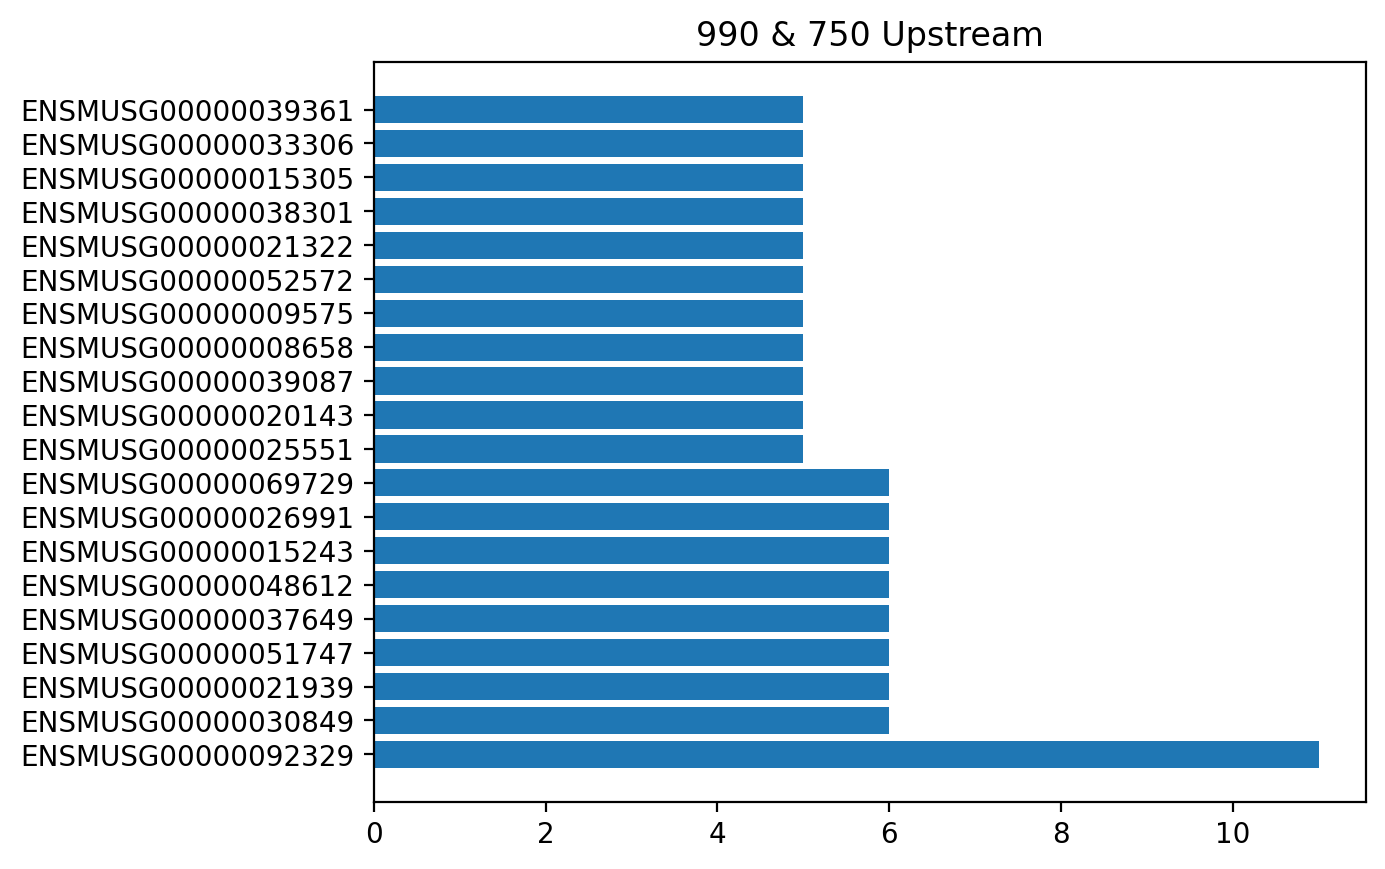

In [27]:
plt.figure(dpi=200)
plt.title("{} & 750 Upstream".format(threshold))

plt.barh(value_counts[0:20].index.tolist(), value_counts[0:20].to_list())

In [28]:
value_counts.index.size

6240

In [29]:
# pd.Series(value_counts.index[0:500]).to_csv("../outputs/top_500_0.99_genes.txt", header=False, index=False)

## Output Tables to Files

In [30]:
for key in tables: 
    key
    tables[key].to_csv("../outputs/{}.tsv.gz".format(key), sep="\t")

'MA0052.4.upstream_2500'

'MA0052.4.upstream_5000'

'MA0052.4.upstream_750'

'MA0058.3.upstream_2500'

'MA0058.3.upstream_5000'

...

'MA1541.1.upstream_5000'

'MA1541.1.upstream_750'

'MA1557.1.upstream_2500'

'MA1557.1.upstream_5000'

'MA1557.1.upstream_750'